# ***UK HOUSING PRICE AFFORDABILITY INDEX***
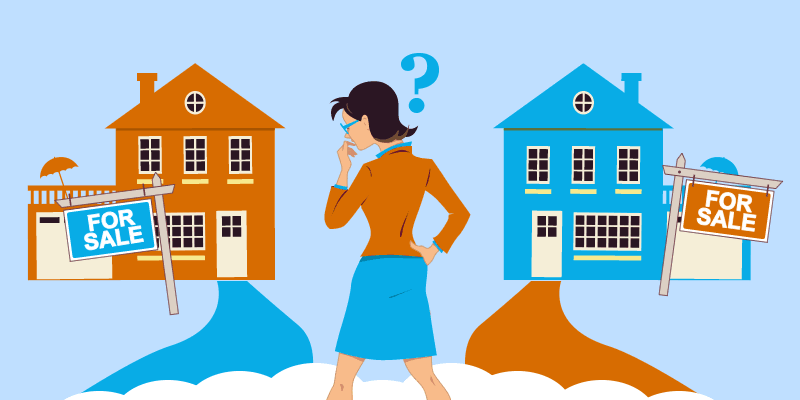

# **Table of content**

1. Introduction
2. Importing Library
3. Data Selection
4. Loading Data
5. Data Preparation
6. Data Analysis
7. Findings
8. Discussion and Recommendation
9. Conclusion
10. Limitations
11. Future Work and Improvements

# **1. Introduction**

The UK housing market has experienced significant changes over the past decade, with house prices rising at a pace that often exceeds income growth. This has raised concerns around housing affordability, particularly for first-time buyers and lower-income households. Understanding the relationship between property prices and earnings is essential for stakeholders such as property investors, financial institutions, and policymakers.

This analysis aims to analyse housing affordability across UK regions by combining data from the UK House Price Index (UKHPI) and the Annual Survey of Hours and Earnings (ASHE). While house prices alone provide insight into market trends, they do not reflect whether individuals can realistically afford to purchase property. Therefore, earnings data is incorporated to create a more meaningful measure of affordability.

To achieve this, an affordability index is calculated by comparing average house prices with median annual earnings. This allows for a clearer understanding of how accessible housing is across different regions and over time. The analysis focuses on identifying trends, regional disparities, and potential areas of financial pressure within the housing market.


## 1.1 Goals

The main goals of this project are:


*   To analyse trends in UK house prices across different regions over time
*   To examine regional income levels using ASHE earnings data
*   To develop an affordability index by comparing house prices with earnings
*   To identify regions where housing affordability is improving or worsening
*   To provide insights that can support investment decisions, lending strategies, and policy development.

## 1.2 **Dataset Description**



The UKHPI dataset provides a comprehensive and detailed view of the housing market, however, for the purpose of this analysis, it was necessary to simplify the dataset by focusing on key variables that directly contribute to measuring affordability, ensuring clarity, consistency, and analytical relevance.

For our analysis we are only focusing on 3 variables from each of our dataset i.e. the year, average house price and region(from UK HPI) with year, average payment and region(from ASHE). The UK HPI dataset contains many variables(54 columns) but for our analysis we are filtering it on yearly basis. There are many cities as well as their regions are mentioned in UK HPI dataset, for example Aberdeenshire and Scotland both are mentioned, which will lead to data ambiguity. Hence, we are filtering it based on regions like Scotland, East Midlands, London etc. The date is also mentioned month wise, hence, we will be taking it as yearly based. We are also taking the Average House prices which is one of the 3 most important variables in our analysis. Lastly we are keeping a range of years from 2016-2023 in both datasets for better analysis.

In ASHE data set which is the for the annual income for indivisuals, we have many different variables(17 columns). One of the most important column is **v4_2**, which is the salary column for our analysis. Finally we are filtering the dataset for a better analysis by taking :
**Annual pay - Gross** from **HoursAndEarnings**,
**Full-Time** employement from **WorkingPattern**,
**Median** of the income from **AveragesAndPercentiles**, and
in the **Sex** column we have Male, Female and All, so we are filtering it with **All**. Lastly, the year range is similar as UK HPI from 2016-2023.

# **2. Importing Libarry**

To perform data cleaning, analysis, and visualisation, several Python libraries were imported using the following code.

These libraries provide the necessary tools for efficient data processing, analysis, and visualisation, enabling the transformation of raw data into meaningful insights.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

# **3. Data Selection**


Data used:
1. [UK House Price Index (UK HPI) from HM Land Registry (regional average prices over time](https://www.google.com/search?q=https%3A%2F%2Fpublicdata.landregistry.gov.uk%2Fmarket-trend-data%2Fhouse-price-index-data%2Fuk-hpi-full-file-2025-12.csv)
2. [Annual Survey of Hours and Earnings (ASHE) – Table 25 from ONS (earnings by UK region](https://www.ons.gov.uk/datasets/ashe-tables-25/editions/time-series/versions)

Why these datasets?  
House prices alone don’t show affordability. By combining UK HPI prices
with ONS earnings, we can calculate an affordability index and identify
regions where price growth is outpacing income, making it a key signal for investment risk and mortgage stress.

# **4. Load Data**



## 4.1 UK HPI House Price

In [ ]:
url = "https://www.dropbox.com/scl/fi/xkpw4eu0rwrgjs120rh6x/UK-HPI.csv?rlkey=zmhhxngzfh5ianeblgwc7n1fn&st=3urlzhly&dl=1"
hpi = pd.read_csv(url)
hpi

,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,...,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,...,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,...,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,...,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,...,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149080,01/08/2025,Yorkshire and The Humber,E12000003,206107,107.6,105.8,0.9,2.0,202741.0,5471.0,...,302627.0,112.1,-0.9,7.4,19.0,202629.0,107.3,1.0,1.8,5452.0
149081,01/09/2025,Yorkshire and The Humber,E12000003,206581,107.8,106.9,0.2,3.9,204762.0,4745.0,...,306535.0,113.5,1.3,10.2,18.0,202921.0,107.5,0.1,3.5,4727.0
149082,01/10/2025,Yorkshire and The Humber,E12000003,206401,107.7,106.7,-0.1,3.2,204537.0,4961.0,...,313072.0,115.9,2.1,10.3,8.0,202381.0,107.2,-0.3,2.8,4953.0
149083,01/11/2025,Yorkshire and The Humber,E12000003,209467,109.3,108.0,1.5,3.8,206882.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.1.1 Understanding UK HPI data.

After loading the UK House Price Index (UKHPI) dataset, the dataset contains around 149,000 rows and 54 columns including a wide range of variables describing property prices across regions, time, and property categories. Each row represents a monthly observation for a specific region, making the dataset a time-series panel dataset. This means the dataset captures how house prices change over time across multiple geographic locations.

The dataset includes variables such as:

* Region names
* Dates (monthly)
* Average house prices
* Property types and transaction details

Due to its detailed structure, the dataset provides a comprehensive view of housing market trends in the UK. However, not all variables are required for this analysis. For the purpose of this analysis, the focus is placed on key variables such as Date, Region, and Average House Price, which are essential for analysing housing affordability.

The monthly nature of the dataset allows for detailed tracking of price changes, but it also introduces short-term fluctuations. Therefore, the data is later aggregated into annual values to provide a more stable and meaningful representation for comparison with earnings data.

### 4.1.2 Checking the datatypes of each column.

To understand the structure and format of the UK HPI dataset, the following command was used:

In [ ]:
hpi.dtypes

,0
Date,object
RegionName,object
AreaCode,object
AveragePrice,int64
Index,float64
IndexSA,float64
1m%Change,float64
12m%Change,float64
AveragePriceSA,float64
SalesVolume,float64


#### 4.1.2a Datatype explanation :

The **dtypes** function is used to display the data type of each column in the dataset. This helps in identifying whether the variables are stored as:

* object (text/string)
* int (integer)
* float (decimal numbers)

Checking data types is an important step before data cleaning and analysis because in the UK HPI dataset, the Date column is stored as an object (string) rather than a datetime format. This means time-based operations, such as extracting the year or analysing trends, cannot be performed until it is converted.

## 4.2 Load ONS ASHE Earnings Data

In [ ]:
url = "https://www.dropbox.com/scl/fi/cs5czhlzl1719veudgfzw/ashe-time-series.csv?rlkey=u38jcgxeq3o2esrknkk9yei8l&st=70a9v48s&dl=1"
ashe = pd.read_csv(url)
ashe

,v4_2,Data Marking,CV,calendar-years,Time,administrative-geography,Geography,averages-and-percentiles,AveragesAndPercentiles,sex,Sex,working-pattern,WorkingPattern,hours-and-earnings,HoursAndEarnings,sector,Sector
0,764.8,NaN,2.4,2016,2016,E12000005,West Midlands,80,80th percentile,all,All,full-time,Full-Time,basic-pay-including-other-pay,Basic pay - Including other pay,public-sector,Public sector
1,NaN,x,21.0,2018,2018,E12000005,West Midlands,25,25th percentile,male,Male,part-time,Part-Time,overtime-pay,Overtime pay,private-sector,Private sector
2,37.0,NaN,0.2,2019,2019,E12000005,West Midlands,25,25th percentile,male,Male,full-time,Full-Time,paid-hours-worked-total,Paid hours worked - Total,all,All
3,6723.0,NaN,2.8,2020,2020,E12000005,West Midlands,10,10th percentile,female,Female,all,All,annual-pay-gross,Annual pay - Gross,all,All
4,NaN,x,24.0,2016,2016,E12000005,West Midlands,10,10th percentile,male,Male,part-time,Part-Time,paid-hours-worked-total,Paid hours worked - Total,non-profit-body-or-mutual-association,Non-profit body or mutual association
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456187,4967.0,NaN,18.0,2022,2022,E12000008,South East,75,75,female,Female,full-time,Full-Time,annual-pay-incentive,Annual pay - Incentive,all,All
456188,NaN,x,x,2022,2022,E12000008,South East,75,75,female,Female,full-time,Full-Time,annual-pay-incentive,Annual pay - Incentive,public-sector,Public sector
456189,1417.0,NaN,14.0,2022,2022,E12000008,South East,40,40,female,Female,full-time,Full-Time,annual-pay-incentive,Annual pay - Incentive,private-sector,Private sector
456190,6928.0,NaN,19.0,2022,2022,E12000008,South East,80,80,female,Female,full-time,Full-Time,annual-pay-incentive,Annual pay - Incentive,private-sector,Private sector


### 4.2.1 Understanding ASHE data.

After loading the Office for National Statistics (ONS) Annual Survey of Hours and Earnings (ASHE) dataset, the dataset contains a large number of rows and multiple columns representing earnings information across different regions, years, and categories. The dataset includes various dimensions such as gender, working pattern, percentiles, sector, and different types of pay.

Each row represents an observation for a specific region, year, and earnings category, making the dataset a structured panel dataset with both cross-sectional and time-series characteristics. Unlike the UK HPI dataset, which focuses on monthly house prices, the ASHE dataset provides annual earnings data, allowing for consistent comparison over time.

The dataset is more complex in structure due to the presence of multiple classifications, such as hourly, weekly, and annual pay, as well as different percentiles and employment types. Therefore, it requires careful filtering to extract a standardised and comparable measure of earnings.

### 4.2.2 Checking the datatypes of each column.

To understand the structure and format of the ASHE dataset, the following command was used:

In [ ]:
ashe.dtypes

,0
v4_2,float64
Data Marking,object
CV,object
calendar-years,int64
Time,int64
administrative-geography,object
Geography,object
averages-and-percentiles,object
AveragesAndPercentiles,object
sex,object


#### 4.2.2a Datatype explanation :
The date(calender-year and Time) are in int64 format which also have to be changed into datetime foramt.

# **5. Data Preparation**

Data preparation is a critical stage in the data analysis process, as it ensures that raw data is transformed into a clean, structured, and usable format. In this affordability analysis, data preparation involves cleaning, filtering, transforming, and integrating data from two different sources, the UK House Price Index (UK HPI) dataset and the ONS Annual Survey of Hours and Earnings (ASHE) dataset.

Both datasets initially contain a large number of variables and complex structures, which are not directly suitable for analysis. Therefore, several preprocessing steps are required to extract only the relevant information and ensure consistency between the datasets.



## 5.1 Prepare UK HPI

In the dataset, we are only focusing on the columns that are important for our analysis i.e. the "Year", "RegionName" and "AveragePrice" of houses.

We also have to remove the null or missing values from the dataset for a clear understanding of the data.

We are grouping the date into a range of 2016 - 2023 for a better comparision.

In [ ]:
# 1) Keep only key columns
hpi = hpi[['Date', 'RegionName', 'AveragePrice']].copy()

# 2) Convert Date to datetime
hpi['Date'] = pd.to_datetime(hpi['Date'], errors='coerce')

# 3) Remove missing
hpi = hpi.dropna(subset=['Date', 'RegionName', 'AveragePrice'])

# 4) Make Year
hpi['Year'] = hpi['Date'].dt.year

# 5) Filter to a sensible range (improves clarity and reduces noise)
hpi = hpi[(hpi['Year'] >= 2016) & (hpi['Year'] <= 2023)]

# 6) Aggregate monthly to annual mean per region
hpi_annual = (hpi
              .groupby(['Year','RegionName'], as_index=False)
              .agg(AvgHousePrice=('AveragePrice','mean')))

hpi_annual['AvgHousePrice'] = hpi_annual['AvgHousePrice'].round(2)

hpi_annual


,Year,RegionName,AvgHousePrice
0,2016,Aberdeenshire,202646.83
1,2016,Adur,294245.42
2,2016,Amber Valley,148560.75
3,2016,Angus,135536.08
4,2016,Antrim and Newtownabbey,119471.00
...,...,...,...
3235,2023,Wychavon,314937.75
3236,2023,Wyre,183013.92
3237,2023,Wyre Forest,229260.92
3238,2023,York,305336.08


### 5.1.1 Dataset Cleaning explanation :

As mentioned before, for our affordability analysis we only need 3 variables, Date, Region and Average House Price. In :

1. We are keeping only the important columns that are important for our analysis and making a copy of this dataset so all the cleaning in next steps are performed on the copy and the original dataset remains safe.

2. Since our date was in obj format, the time analysis can not be performed on the dataset. So, we are changing the obj into datetime format. It is also important to mention the importance of 'coerce' command used. Without using the **errors='coerce'**, if we run the command and there are any null values in the dataset, the command will not run and throw an error, but by using the command, we are informing that if there is any null value while running the command, fill it with NaN value and run the command without showing any error.

3. In cleaning step 3, we are removing all the missing values from the 3 variables that we have selected in command 1.

4. In the UK HPI dataset, the date is mentioned month wise. We are changing the monthly date into yearly basis for better analysis.

5. In the 5th cleaning step, as mentioned previously, to make a sensible analysis, we are taking a range of year from 2016 - 2023.

6. The 6th cleaning step is one of the most important step. The UKHPI dataset provides monthly observations, which can introduce short-term fluctuations and noise. Therefore, the data was grouped by year and region, and the mean house price was calculated to obtain a more stable and representative annual value. This also ensures consistency when merging with earnings data, which is reported annually. Lastly the average was reduced to a 2 decimal digit by using 'round(2)' command.

### **5.1.2 Checking the regions mentioned in the UK HPI dataset.**

Our UK HPI dataset has many cities as well as regions mentioned in the column "RegionName". With the 'sorted' command with 'dropna()' and 'unique()' we are first removing all the null values and then taking only the unique names to make sure there are no duplicate entries and then getting the details output for further filtering according to region wise so that we can analysis based on regions rather than individual cities.  

In [ ]:
sorted(hpi_annual['RegionName'].dropna().unique())

['Aberdeenshire',
 'Adur',
 'Amber Valley',
 'Angus',
 'Antrim and Newtownabbey',
 'Ards and North Down',
 'Argyll and Bute',
 'Armagh City Banbridge and Craigavon',
 'Arun',
 'Ashfield',
 'Ashford',
 'Babergh',
 'Barking and Dagenham',
 'Barnet',
 'Barnsley',
 'Basildon',
 'Basingstoke and Deane',
 'Bassetlaw',
 'Bath and North East Somerset',
 'Bedford',
 'Belfast',
 'Bexley',
 'Birmingham',
 'Blaby',
 'Blackburn with Darwen',
 'Blackpool',
 'Blaenau Gwent',
 'Bolsover',
 'Bolton',
 'Boston',
 'Bournemouth Christchurch and Poole',
 'Bracknell Forest',
 'Bradford',
 'Braintree',
 'Breckland',
 'Brent',
 'Brentwood',
 'Bridgend',
 'Brighton and Hove',
 'Broadland',
 'Bromley',
 'Bromsgrove',
 'Broxbourne',
 'Broxtowe',
 'Buckinghamshire',
 'Burnley',
 'Bury',
 'Caerphilly',
 'Calderdale',
 'Cambridge',
 'Cambridgeshire',
 'Camden',
 'Cannock Chase',
 'Canterbury',
 'Cardiff',
 'Carmarthenshire',
 'Castle Point',
 'Causeway Coast and Glens',
 'Central Bedfordshire',
 'Ceredigion',
 'Cha

### **5.1.3 Filtering the data based on regions like Scotland, East Midlands, London etc.**

After sorting and removing duplicates and null values, we are filtering the UK HPI dataset by regions that are covered in our analysis. We are also using the 'copy()' command to make a copy of this filtered data to use for our next processes.

In [ ]:
regions = [
    'East', 'East Midlands', 'London', 'North East', 'North West', 'Scotland', 'South East', 'South West', 'United Kingdom', 'Wales', 'West Midlands', 'Yorkshire and The Humber'
]

hpi_annual_region = hpi_annual[hpi_annual['RegionName'].isin(regions)].copy()
hpi_annual_region

,Year,RegionName,AvgHousePrice
113,2016,East Midlands,163698.00
201,2016,London,500486.75
236,2016,North East,117724.08
248,2016,North West,137136.00
289,2016,Scotland,133519.42
...,...,...,...
3148,2023,South West,303559.33
3193,2023,United Kingdom,258956.17
3198,2023,Wales,201222.50
3215,2023,West Midlands,223234.75


### **5.1.4 Changing the column name.**

We are changing the column "RegionName" into "Region" to maintain naming standards.  

In [ ]:
hpi_annual_region_standardised = hpi_annual_region.rename(columns={'RegionName': 'Region'})
hpi_annual_region_standardised

,Year,Region,AvgHousePrice
113,2016,East Midlands,163698.00
201,2016,London,500486.75
236,2016,North East,117724.08
248,2016,North West,137136.00
289,2016,Scotland,133519.42
...,...,...,...
3148,2023,South West,303559.33
3193,2023,United Kingdom,258956.17
3198,2023,Wales,201222.50
3215,2023,West Midlands,223234.75


## **5.2 Prepare ASHE**

In the dataset, similar to UK HPI dataset, we are focusing on the columns that are important for our analysis i.e. the "Year", "Region" and "Yearly Income" of individuals.

We also have to remove the null or missing values from the dataset for a clear understanding of the data.

The dataset is already in the range of 2016 - 2023 which is in the similar range of our UK HPI dataset.

In [ ]:
ashe_clean = ashe.copy()

# Keep only relevant salary rows
ashe_clean = ashe_clean[
    (ashe_clean['HoursAndEarnings'] == 'Annual pay - Gross') &
    (ashe_clean['Sex'] == 'All') &
    (ashe_clean['WorkingPattern'] == 'Full-Time') &
    (ashe_clean['AveragesAndPercentiles'] == 'Median')
]

# Select required columns
ashe_clean = ashe_clean[['Geography', 'calendar-years', 'v4_2']]

# Rename columns
ashe_clean.columns = ['Region', 'Year', 'Earnings']

# Convert types
ashe_clean['Year'] = pd.to_numeric(ashe_clean['Year'], errors='coerce')
ashe_clean['Earnings'] = pd.to_numeric(ashe_clean['Earnings'], errors='coerce')

# Drop missing
ashe_clean = ashe_clean.dropna()

ashe_clean

,Region,Year,Earnings
2157,West Midlands,2020,32362.0
2920,West Midlands,2023,33003.0
3677,West Midlands,2021,32430.0
4003,West Midlands,2017,26289.0
6323,West Midlands,2017,28686.0
...,...,...,...
450918,South East,2020,33148.0
451788,South East,2022,34500.0
451960,South East,2018,30703.0
453026,South East,2022,35001.0


### **5.2.1 Dataset cleaning explanation.**

As discussed earlier, for our affordability analysis we require only three key variables from the ASHE dataset: Region, Year, and Earnings. However, unlike the UK HPI dataset, the ASHE dataset is more complex and contains multiple dimensions such as gender, working patterns, percentiles, and different types of earnings.

So, to filter the variables that are necessary we followed these steps :

1. In the first step, we create a copy of the dataset so that all cleaning and transformations are performed on the duplicate dataset, ensuring that the original dataset remains unchanged and can be referred back to if required.

2. In the next step, we filter the dataset to keep only the relevant salary information.

This is one of the most important steps in the cleaning process. The ASHE dataset includes various types of earnings such as hourly pay, weekly pay, overtime pay, and different percentiles. However, for a meaningful affordability comparison, we require a consistent and representative measure of income.

Therefore:

*   Annual pay - Gross ensures we are using yearly salary rather than hourly or weekly values.
*   Sex = All ensures inclusivity and avoids bias towards a specific group.

*   Full-Time ensures consistency when comparing earnings across regions.

*   Median is chosen instead of mean to reduce the impact of extreme values

This step ensures that we are extracting a standardised salary measure that can be reliably compared with house prices.

3. In the third step, we select only the required columns :


*   Geography → represents the region
*   calendar-years → represents the year
*   v4_2 → contains the actual earnings values

This simplifies the dataset by removing unnecessary variables and focusing only on the data required for affordability analysis.

4. Next, we rename the columns for better clarity. This improves readability and ensures consistency when merging with the UK HPI dataset.

5. In the next step, we convert the data types of Year and Earnings into numeric format. This is necessary because numerical operations and comparisons cannot be performed on non-numeric data types.
The use of **errors='coerce'** ensures that any invalid or non-numeric values are automatically converted into NaN, allowing the code to execute without errors.

6. Finally, in the last step, we remove all missing values from the dataset. This ensures that the final dataset is clean and free from incomplete records, which could otherwise affect the accuracy of the analysis.

The cleaning process ensures that the earnings data is consistent, reliable, and directly comparable with housing price data, which is essential for accurately measuring housing affordability across regions and over time.

### 5.2.2  Data Aggregation (ASHE)

After cleaning the ASHE dataset, it was observed that there were still multiple entries for the same Region and Year. This is because the dataset may contain slight variations or multiple records for the same category even after filtering.

To resolve this, the following step was performed:

In [ ]:
ashe_final = ashe_clean.groupby(['Region', 'Year'], as_index=False).agg({
    'Earnings': 'mean'
})
ashe_final

,Region,Year,Earnings
0,East,2016,28483.00
1,East,2017,28783.25
2,East,2018,29433.25
3,East,2019,30592.75
4,East,2020,31417.75
...,...,...,...
91,Yorkshire and The Humber,2019,28311.75
92,Yorkshire and The Humber,2020,28583.50
93,Yorkshire and The Humber,2021,29117.00
94,Yorkshire and The Humber,2022,30848.75


### 5.2.3 Data Validation (Region Check)

To ensure that the dataset contains consistent and correct regional values, the following command was used:


In [ ]:
sorted(ashe_final['Region'].dropna().unique()[:50])

['East',
 'East Midlands',
 'London',
 'North East',
 'North West',
 'Scotland',
 'South East',
 'South West',
 'United Kingdom',
 'Wales',
 'West Midlands',
 'Yorkshire and The Humber']

**Explanation for Data Validation.**

This step helps in verifying the distinct regions present in the dataset.

The command works in multiple parts:

**ashe_final['Region']** selects the Region column from the dataset
**.dropna()** removes any missing or null values, ensuring that only valid region names are considered
**.unique()** extracts all distinct region values, removing duplicates
**[:50] **limits the output to the first 50 values, which is useful for quick inspection when working with large datasets
**sorted()** arranges the region names in alphabetical order, making them easier to read and compare

This step is important for several reasons:

* It ensures that region names are consistent and correctly formatted.
* It helps identify any unexpected or incorrect region values
* It allows verification that the regions align with those in the UK HPI dataset before merging
* It helps detect issues such as spelling variations or mismatches that could cause problems during merging.

**This validation step ensures consistency in regional data, reducing the risk of mismatches during dataset merging and improving the overall reliability of the analysis.**

## **5.3 Data Merging**

After cleaning and preparing both datasets, the next step is to combine the UK HPI dataset with the ASHE earnings dataset. This is done using the following command:

In [ ]:
merged = pd.merge(
    hpi_annual_region_standardised,
    ashe_final,
    left_on=['Region', 'Year'],
    right_on=['Region', 'Year'],
    how='inner'
)

merged

,Year,Region,AvgHousePrice,Earnings
0,2016,East Midlands,163698.00,26490.50
1,2016,London,500486.75,35986.75
2,2016,North East,117724.08,25843.50
3,2016,North West,137136.00,26674.50
4,2016,Scotland,133519.42,28208.25
...,...,...,...,...
83,2023,South West,303559.33,33487.75
84,2023,United Kingdom,258956.17,35017.75
85,2023,Wales,201222.50,33011.00
86,2023,West Midlands,223234.75,33318.50


### 5.3.1 Data merging explanation.

This step merges the two datasets based on two key variables:

* Region → ensures geographical alignment between datasets
* Year → ensures temporal consistency

The **pd.merge()** function combines the datasets by matching rows where both the Region and Year values are the same in each dataset.

The parameter **how='inner'** is used to perform an inner join. This means that:

* Only the rows that have matching Region and Year values in both datasets are included
* Any unmatched rows are excluded

This ensures that the final dataset contains only complete and comparable observations, which is essential for accurate analysis.

Before performing the merge, the region names in the UK HPI dataset were standardised to match those in the ASHE dataset. This step was necessary because inconsistencies in naming conventions (e.g., formatting differences) can lead to mismatches during merging.

Each row now represents a unique combination of region and year, with both housing prices and earnings available for comparison.

This merged dataset forms the foundation for the next step, which is the calculation of the affordability index. By combining house price data with earnings data, we can directly measure how affordable housing is across different regions and over time.

## **5.4 Affordability Index Calculation**

After successfully merging the UK HPI and ASHE datasets, the final step is to calculate the affordability index using the following command:

In [ ]:
merged['AffordabilityIndex'] = merged['AvgHousePrice'] / merged['Earnings']
merged

,Year,Region,AvgHousePrice,Earnings,AffordabilityIndex
0,2016,East Midlands,163698.00,26490.50,6.179498
1,2016,London,500486.75,35986.75,13.907528
2,2016,North East,117724.08,25843.50,4.555268
3,2016,North West,137136.00,26674.50,5.141090
4,2016,Scotland,133519.42,28208.25,4.733346
...,...,...,...,...,...
83,2023,South West,303559.33,33487.75,9.064787
84,2023,United Kingdom,258956.17,35017.75,7.394997
85,2023,Wales,201222.50,33011.00,6.095620
86,2023,West Midlands,223234.75,33318.50,6.700024


### 5.4.1 **What the affordability index means**

This step creates a new column called AffordabilityIndex, which represents the ratio between:

* Average House Price (AvgHousePrice)
* Annual Earnings (Earnings)

**The formula is:**

AffordabilityIndex = Average House Price / Annual Earnings

**Example:**

House price = £300,000
Salary = £30,000

Then:

300000 / 30000 = 10

## *This means the average house costs 10 times annual salary.*

**So:**

**Higher value = less affordable**

**Lower value = more affordable**

# **6. Data Analysis**

In this project, data analysis is used to understand the relationship between house prices and earnings, and to evaluate how housing affordability has changed across different regions and over time.

The primary objective of the analysis is to identify patterns, trends, and regional differences in housing affordability. By using the affordability index, which combines both housing prices and income levels, the analysis provides a more comprehensive understanding of whether individuals can realistically afford to purchase property in different areas.

## 6.1 Trend Analysis: Affordability Index Over Time

To analyse how housing affordability has changed over time across different regions, a multi-line chart was created using the following code:

In [ ]:
import plotly.express as px

fig_line = px.line(
    merged,
    x='Year',
    y='AffordabilityIndex',
    color='Region',
    color_discrete_sequence=px.colors.qualitative.Safe,
    markers=True,
    title='Affordability Index Over Time by Region',
    labels={
        'Year': 'Year',
        'AffordabilityIndex': 'Affordability Index',
        'Region': 'Region'
    }
)

fig_line.update_layout(
    template='plotly_white',
    title_x=0.5
)

fig_line.show()

### 6.1.1 Purpose of the Visualisation

This graph is used to perform temporal analysis, showing how the affordability index has evolved over time for each region. The multi-line format allows multiple regions to be compared simultaneously within a single visual.

### 6.1.2 Explanation of the Code

* **px.line()** is used to create a line chart, which is ideal for showing trends over time
* **Year** is placed on the x-axis to represent time progression
* **AffordabilityIndex** is placed on the y-axis to show changes in affordability
* **color='Region'** assigns a different line to each region, enabling comparison
* **markers=True** adds points to each year, improving readability
* **color_discrete_sequence=px.colors.qualitative.Safe** ensures the chart is colour-blind friendly
* **template='plotly_white'** provides a clean and professional layout

### 6.1.3 Interpretation of the Graph

The line chart allows us to observe several key patterns:

* Most regions show an upward trend in the affordability index, indicating that housing has become less affordable over time
* Regions with steeper slopes represent areas where house prices have increased faster relative to earnings
* Some regions may show fluctuations, reflecting short-term changes in the housing market
* Differences between regions highlight regional inequality in housing affordability


### 6.1.4  Key Insights

* Housing affordability has generally declined across the UK over the selected time period
* Certain regions (e.g., London and South East) typically show higher affordability index values, indicating greater housing pressure
* Regions with lower values indicate relatively better affordability, though trends may still show gradual decline.

This visualisation effectively highlights long-term affordability trends and provides a clear comparison across regions, forming the basis for deeper regional and comparative analysis in subsequent sections.

## 6.2 Regional Comparison: Affordability Ranking by Region

To compare housing affordability across different regions for the most recent year, a bar chart was created using the following code:

In [ ]:
latest_year = merged['Year'].max()

bar_df = merged[merged['Year'] == latest_year].sort_values('AffordabilityIndex')

fig_bar = px.bar(
    bar_df,
    x='Region',
    y='AffordabilityIndex',
    color='AffordabilityIndex',
    color_continuous_scale='Cividis_r',
    title=f'Affordability Ranking by Region in {latest_year}',
    labels={
        'Region': 'Region',
        'AffordabilityIndex': 'Affordability Index'
    },
    text_auto='.2f'
)

fig_bar.update_layout(
    template='plotly_white',
    title_x=0.5,
    xaxis_tickangle=-45
)

fig_bar.show()

### 6.2.1 Purpose of the Visualisation

This visualisation is used to perform spatial analysis, focusing on comparing housing affordability across regions in a single year. By selecting the latest available year, the graph provides a current snapshot of affordability across the UK.

### 6.2.2 Explanation of the Code

* **latest_year = merged['Year'].max()** identifies the most recent year in the dataset
* The dataset is filtered to include only that year
**.sort_values('AffordabilityIndex')** arranges regions from most affordable to least affordable
* **px.bar()** creates a bar chart for comparison across regions
* **color='AffordabilityIndex'** applies a gradient colour scale based on affordability levels
* **color_continuous_scale='Cividis_r'** ensures the chart is colour-blind friendly and visually clear
* **text_auto='.2f'** displays the exact values on each bar for better readability

### 6.2.3 Interpretation of the Graph

The bar chart provides a clear comparison of affordability across regions:

* Regions with higher bars have a higher affordability index, meaning housing is less affordable
* Regions with lower bars are relatively more affordable
* The ordered structure makes it easy to identify the most and least affordable regions

### 6.2.4 Key Insights

* There is a noticeable variation in affordability across regions
* Some regions show significantly higher affordability index values, indicating greater housing pressure
* Other regions remain relatively more affordable, though differences may still be narrowing over time
* The ranking highlights regional inequality in housing affordability

This visualisation provides a clear and intuitive comparison of regional affordability, enabling the identification of areas with the highest housing pressure and supporting more informed analysis of spatial disparities.

## 6.3 Comparative Analysis: Affordability Change (2016 vs 2023)

To compare how housing affordability has changed over time, a clustered bar chart was created for two selected years, 2016 and 2023, using the following code:

In [ ]:
# Filter only 2016 and 2023
compare_df = merged[merged['Year'].isin([2016, 2023])].copy()

# Sort regions by 2023 affordability
order = compare_df[compare_df['Year'] == 2023]\
    .sort_values('AffordabilityIndex')['Region']

compare_df['Region'] = pd.Categorical(compare_df['Region'], categories=order, ordered=True)

# Creating a clustered bar chart
fig_bar = px.bar(
    compare_df,
    x='Region',
    y='AffordabilityIndex',
    color='Year',
    barmode='group',
    color_discrete_sequence=['#7A7A7A', '#0072B2'],  # grey (2016), blue (2023)
    title='Housing Affordability Comparison (2016 vs 2023)',
    labels={
        'Region': 'Region',
        'AffordabilityIndex': 'Affordability Index',
        'Year': 'Year'
    },
    text_auto='.2f'
)
fig_bar.show()

### 6.3.1 Purpose of the Visualisation

This visualisation is used to perform a comparative analysis between two time points. By focusing on 2016 and 2023, the chart highlights how affordability has changed over a defined period, making it easier to identify trends and differences across regions.

### 6.3.2 Explanation of the Code

* The dataset is filtered to include only the years 2016 and 2023, ensuring a focused comparison
* **Regions** are sorted based on 2023 affordability values, improving readability
* **pd.Categorical()** is used to enforce this order in the chart
* **px.bar()** creates a clustered (grouped) bar chart
barmode='group' places the bars for each year side-by-side for direct comparison
* A colour scheme is applied:

  a. Grey represents 2016

  b. Blue represents 2023
* **text_auto='.2f'** displays exact values on the bars for clarity

### 6.3.3 Interpretation of the Graph

The clustered bar chart allows for a clear comparison of affordability between the two years:

* In most regions, the bar representing 2023 is higher than 2016, indicating a rise in the affordability index
* This suggests that house prices have increased faster than earnings over time
* The side-by-side structure makes it easy to observe both the direction and magnitude of change

### 6.3.4 Key Insights

* Housing affordability has generally worsened across the UK between 2016 and 2023.
* Some regions show a larger gap between the two years, indicating a more significant decline in affordability
* Regions with consistently high values represent areas under greater housing pressure.
* The comparison highlights how affordability trends differ across regions, reflecting regional disparities.

This visualisation provides a clear and effective comparison of affordability over time, highlighting the extent to which housing accessibility has changed across regions and supporting a deeper understanding of long-term trends.

## 6.4 Spatial–Temporal Analysis: Animated Affordability Map (2016–2023)

To analyse how housing affordability has changed across regions over time, a Mapbox-based animated visualisation was created. This allows both spatial (regional) and temporal (time-based) patterns to be observed simultaneously.

### 6.4.1 Upload the token from mapbox.

The **mapbox.txt** file is used to securely store the Mapbox access token, which is required to generate Mapbox-based visualisations in Plotly.

**Mapbox** is a mapping service that provides the background maps and geographic rendering used in the animated affordability visualisation. In order to access these services, an API access token is required.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mapbox.txt to mapbox.txt


### 6.4.2 Read the mapbox.txt

Instead of writing the token directly in the code, it is stored in a separate file (**mapbox.txt**) and loaded during execution.
This approach is important for several reasons:

* API tokens are sensitive information
* Separating credentials from code is a standard industry practice

In [ ]:
px.set_mapbox_access_token(open("/content/mapbox.txt").read())

### 6.4.3 Data Preparation for Map-Based Visualisation

Before creating the Mapbox visualisation, additional data preparation steps were required to ensure that the dataset was suitable for geographic mapping and time-based animation.

In [ ]:
# Approximate coordinates for UK regions
region_coords = {
    'North East': (54.7290, -1.8810),
    'North West': (53.7632, -2.7031),
    'Yorkshire and the Humber': (53.9915, -1.5412),
    'East Midlands': (52.7955, -0.9740),
    'West Midlands': (52.4862, -2.0030),
    'East of England': (52.2405, 0.9027),
    'London': (51.5074, -0.1278),
    'South East': (51.2748, -0.5216),
    'South West': (50.7772, -3.9995),
    'Wales': (52.1307, -3.7837),
    'Scotland': (56.4907, -4.2026),
    'Northern Ireland': (54.7877, -6.4923)
}

coords_df = pd.DataFrame(
    [{'Region': r, 'lat': lat, 'lon': lon} for r, (lat, lon) in region_coords.items()]
)

map_df = merged.merge(coords_df, on='Region', how='left')

map_df

,Year,Region,AvgHousePrice,Earnings,AffordabilityIndex,lat,lon
0,2016,East Midlands,163698.00,26490.50,6.179498,52.7955,-0.9740
1,2016,London,500486.75,35986.75,13.907528,51.5074,-0.1278
2,2016,North East,117724.08,25843.50,4.555268,54.7290,-1.8810
3,2016,North West,137136.00,26674.50,5.141090,53.7632,-2.7031
4,2016,Scotland,133519.42,28208.25,4.733346,56.4907,-4.2026
...,...,...,...,...,...,...,...
83,2023,South West,303559.33,33487.75,9.064787,50.7772,-3.9995
84,2023,United Kingdom,258956.17,35017.75,7.394997,NaN,NaN
85,2023,Wales,201222.50,33011.00,6.095620,52.1307,-3.7837
86,2023,West Midlands,223234.75,33318.50,6.700024,52.4862,-2.0030


#### 6.4.3a Data Preparation Explanation.

* Assigning Geographic Coordinates :

Since the dataset does not contain latitude and longitude values, approximate centroid coordinates are assigned to each UK region.

These coordinates represent the central location of each region and allow the data to be plotted on a map. This step is essential because Mapbox requires geographic coordinates to display data spatially.

* Converting Coordinates into a DataFrame :

The coordinate dictionary is converted into a structured DataFrame so that it can be merged with the main dataset. This ensures that each region has corresponding latitude and longitude values.

* Merging Coordinates with the Dataset :

This step combines the affordability dataset with the geographic coordinates.

-- The merge is performed on the Region column.

-- A left join ensures that all affordability data is retained.

-- Each region is now associated with its corresponding location.

### 6.4.4 Animated Mapbox Visualisation

To analyse how housing affordability has changed across UK regions over time, an animated Mapbox visualisation was created using the following code:

In [ ]:
fig_anim = px.scatter_mapbox(
    map_df,
    lat='lat',
    lon='lon',
    color='AffordabilityIndex',
    size='AffordabilityIndex',
    animation_frame='Year',
    hover_name='Region',
    hover_data={
        'Earnings': ':.0f',
        'AvgHousePrice': ':.2f',
        'AffordabilityIndex': ':.2f',
        'lat': False,
        'lon': False
    },
    color_continuous_scale='Cividis_r',
    size_max=35,
    zoom=4.7,
    center={'lat': 54.2, 'lon': -2.5},
    title='Animated UK Housing Affordability Map (2016–2023)'
)

fig_anim.show()

#### 6.4.4a Purpose of the Visualisation

This visualisation is used to perform spatial and temporal analysis simultaneously. It allows the us to:

* Observe how affordability varies across different regions
* Track how affordability changes year by year
* Identify regions where housing has become less affordable over time
* Understand both geographic patterns and trends in a single visual

#### 6.4.4b Explanation of the code.

The function **px.scatter_mapbox()** is used to create an interactive geographic visualisation based on Mapbox. It allows the data to be plotted on a map using latitude (lat) and longitude (lon) coordinates. This enables the affordability data to be visualised spatially rather than in a traditional chart format.

The **color='AffordabilityIndex'** parameter applies a colour gradient to represent different levels of affordability, while **size='AffordabilityIndex'** adjusts the size of each marker based on the same variable. Together, these features make it easier to visually distinguish regions with higher or lower affordability pressure.

The **animation_frame='Year'** parameter introduces a time-lapse effect, allowing the map to update year by year. This helps in observing how affordability changes over time. Additionally, **hover_name='Region'** and the **hover_data** argument provide interactive details such as **earnings**, **average house price**, and **affordability index** when we hovers over each region.

To ensure accessibility, the **color_continuous_scale='Cividis_r'** is used, as it is suitable for colour-blind users. The **size_max=35** parameter controls the maximum size of the markers to maintain clarity and avoid overlap. Finally, the **zoom** and **center** settings focus the map on the UK, while the **title** provides a clear description of the visualisation.

#### 6.4.4c Interpretation of the Visualisation

The animated map provides several important insights:

* Each frame represents a different year, allowing changes to be tracked over time
* Regions with larger and darker markers indicate higher affordability index values, meaning housing is less affordable
* The gradual change in marker size and colour shows how affordability evolves across regions
* It becomes easy to identify regions where affordability has consistently worsened over time

#### 6.4.4d Key Insights

* Most regions show an increase in affordability index, indicating declining affordability
* Some regions experience more rapid increases, suggesting stronger housing pressure
* The animation highlights both regional disparities and long-term trends
* It provides a more engaging and intuitive understanding compared to static charts

# **7. Findings**

The analysis of the UK housing market using the affordability index reveals several important patterns and trends across regions and over time.

Firstly, the trend analysis shows a consistent increase in the affordability index across most regions between 2016 and 2023. This indicates that house prices have grown at a faster rate than earnings, leading to a decline in overall housing affordability. The upward trend is visible across multiple visualisations, confirming that this is not a short-term fluctuation but a sustained pattern.

Secondly, the regional comparison highlights significant spatial disparities in affordability. Certain regions, particularly those with higher economic activity, tend to exhibit higher affordability index values, indicating greater housing pressure. In contrast, other regions remain relatively more affordable, although the gap between regions appears to be narrowing over time.

The comparative analysis between 2016 and 2023 further reinforces these findings. Most regions show a noticeable increase in the affordability index, with some regions experiencing a more pronounced rise. This suggests that the imbalance between income growth and housing prices is more severe in specific areas.

Finally, in Spatial-Temporal analysis the animated map provides a comprehensive view of both spatial and temporal changes. It shows that affordability pressures have gradually intensified across the UK, with multiple regions experiencing steady increases in housing costs relative to earnings.

# **8. Discussion and Recommendations**

The findings from this analysis suggest that housing affordability is becoming an increasingly significant issue across the UK. The consistent rise in the affordability index indicates that income growth has not kept pace with rising house prices, which can create barriers for individuals, particularly first-time buyers.

One key implication of this trend is the growing inequality between regions. Areas with already high house prices are becoming even less affordable, which may lead to reduced access to housing and increased financial pressure on households. This could also impact migration patterns, as individuals may move towards more affordable regions, potentially affecting local economies.

From a policy perspective, these findings highlight the need for targeted interventions. Policymakers could focus on increasing housing supply in high-demand areas, promoting affordable housing schemes, and supporting income growth through economic development initiatives. Additionally, improving access to financing options could help reduce the burden on buyers.

From a business and investment perspective, the analysis provides valuable insights into regional housing markets. Investors may identify regions with relatively lower affordability pressure as potential growth opportunities, while also considering long-term risks in highly unaffordable areas.

# **9. Conclusion**

The analysis is aimed to analyse housing affordability across UK regions by combining house price data from the UK HPI dataset with earnings data from the ASHE dataset. By constructing an affordability index, the analysis provided a clear and meaningful measure of how accessible housing is across different regions and over time.

The results show that housing affordability has generally declined between 2016 and 2023, with house prices increasing at a faster rate than earnings. Regional disparities remain evident, highlighting differences in economic conditions and housing demand across the UK.

The use of multiple visualisation techniques, including line charts, bar charts, and Mapbox-based animated maps, enabled a comprehensive understanding of both trends and patterns. These visualisations transformed raw data into clear and actionable insights.

Overall, the analysis demonstrates the importance of combining multiple datasets to gain a deeper understanding of real-world problems. The affordability index serves as a valuable tool for evaluating housing pressure and can support informed decision-making for policymakers, investors, and individuals.

# **10. Limitations**

While the analysis provides valuable insights into housing affordability across the UK, there are several limitations that should be considered.

Firstly, the analysis is based on aggregated regional data, which may mask variations within regions. For example, large regions such as the South East or North West contain both highly expensive and relatively affordable areas. Using regional averages may therefore oversimplify the true distribution of housing affordability.

Secondly, the affordability index is calculated using average house prices and median earnings, which do not fully capture the diversity of individual circumstances. Factors such as household income, employment type, and access to financial support are not considered, which may influence actual affordability at the individual level.

Another limitation relates to the use of approximate geographic coordinates for mapping. Since the dataset does not include precise location data, regional centroids were used to represent each area. While this allows for visualisation, it does not reflect exact geographic boundaries and may reduce spatial accuracy.

Finally, the analysis is limited to the time period 2016 to 2023, which, although recent, does not capture longer-term historical trends or the full impact of economic cycles. External factors such as inflation, interest rates, and policy changes have not been explicitly incorporated into the analysis.



# **11. Future Work and Improvements**

There are several opportunities to enhance and extend this analysis in future work.

Firstly, the analysis could be improved by using more granular data, such as postcode-level information. This would provide a more detailed understanding of affordability variations within regions and allow for more precise insights.

Secondly, additional variables could be incorporated to create a more comprehensive model of affordability. For example, including factors such as interest rates, inflation, mortgage availability, and population growth would provide a deeper understanding of the drivers of housing affordability.

Another potential improvement is the use of advanced analytical techniques, such as predictive modelling or machine learning. This would allow for forecasting future affordability trends and identifying regions at risk of further decline in affordability.

From a visualisation perspective, the project could be enhanced by implementing choropleth maps using geographic boundary data, rather than relying on point-based mapping. This would improve spatial accuracy and provide a more professional representation of regional differences.
